# Wind Resource Analysis in Ireland

Final project for the **Programming for Data Analytics** module.

In this notebook I analyse hourly wind speed data from Met Éireann weather
stations in Ireland to explore how suitable different locations might be for
**wind energy (wind farms)**.

## 1. Introduction and Data Sources
## 2. Imports and Settings
## 3. Data Loading and Cleaning
## 4. Exploratory Analysis (Wind Speed Patterns)
## 5. Simple Wind Power Estimation
## 6. Trend Analysis / Modelling
## 7. Conclusions
## 8. Research Notes and References

## 1. Introduction and Data Sources

The aim of this project is to explore **wind resources in Ireland** using historic
hourly observations from Met Éireann weather stations.

In particular, I want to:

- understand the **distribution of wind speeds** at an Irish station,
- see how wind speed varies by **time of day** and **time of year**,
- build simple **aggregated datasets** (daily and monthly),
- and use a basic model to estimate **potential wind power output**.

For this project I will start with the hourly climate data for:

- **Knock Airport (station 4935)** – hourly observations including wind speed.

The data is available as a CSV file from Met Éireann’s climate data service:

- `https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv`

Later in the notebook I create additional derived datasets (daily and monthly
aggregations) from this raw hourly data and use them for the analysis.

In [3]:
# 2. Imports and Settings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: we may use scikit-learn later for simple trend analysis
from sklearn.linear_model import LinearRegression

# Plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

pd.set_option("display.max_columns", None)

In [4]:
# 3. Data Loading and Cleaning

# URL for Knock Airport (station 4935) hourly data
KNOCK_URL = "https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv"

def load_knock_hourly_wind(url=KNOCK_URL, skiprows=23):
    """
    Load hourly climate data for Knock Airport from Met Éireann.

    Steps:
    - skip the metadata lines at the top of the file
    - parse the 'date' column as a datetime
    - set 'date' as the index
    - ensure the windspeed column ('wdsp') is numeric
    """
    # Read the CSV, skipping the 23-line metadata header
    df = pd.read_csv(url, skiprows=skiprows)

    # Parse date column (format like '10-apr-1996 14:00')
    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    # Sort and set datetime index
    df = df.sort_values("date").set_index("date")

    # Convert windspeed column to numeric (coerce any bad values to NaN)
    df["wdsp"] = pd.to_numeric(df["wdsp"], errors="coerce")

    return df

# Load the data
knock = load_knock_hourly_wind()

print("Knock dataframe shape:", knock.shape)
knock[["temp", "wdsp"]].head()

/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_42235/3148544603.py:17: DtypeWarning: Columns (2,10,12,14,15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, skiprows=skiprows)
/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_42235/3148544603.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True)


Knock dataframe shape: (257898, 20)


,temp,wdsp
date,,
1996-04-10 14:00:00,11.5,0.0
1996-07-31 08:00:00,11.5,0.0
1996-07-31 09:00:00,11.6,0.0
1996-07-31 10:00:00,12.9,0.0
1996-07-31 11:00:00,14.5,0.0


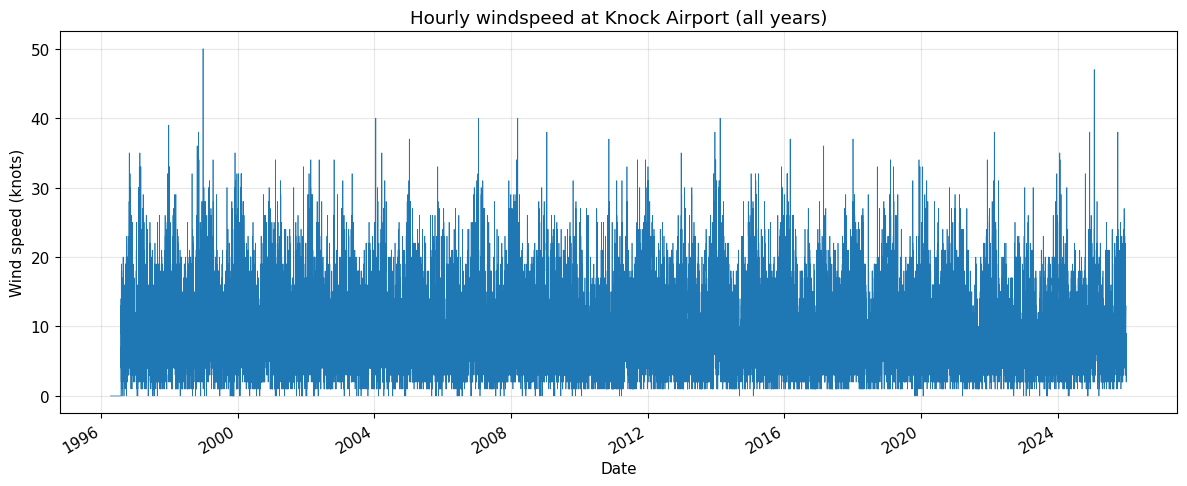

In [5]:
# Quick sanity check plot: hourly windspeed at Knock

plt.figure()
knock["wdsp"].plot(linewidth=0.5)
plt.title("Hourly windspeed at Knock Airport (all years)")
plt.xlabel("Date")
plt.ylabel("Wind speed (knots)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Create daily and monthly aggregated windspeed datasets

# Daily stats: mean, max and min windspeed per day
daily_wind = knock["wdsp"].resample("D").agg(["mean", "max", "min"])

# Monthly stats: mean and max windspeed per month
monthly_wind = knock["wdsp"].resample("M").agg(["mean", "max"])

print("Daily wind shape:", daily_wind.shape)
print("Monthly wind shape:", monthly_wind.shape)

daily_wind.head(), monthly_wind.head()

Daily wind shape: (10859, 3)
Monthly wind shape: (358, 2)


/var/folders/j_/ybtclmn96xv9zbzh98s9m3gm0000gp/T/ipykernel_42235/2076942827.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_wind = knock["wdsp"].resample("M").agg(["mean", "max"])


(            mean  max  min
 date                      
 1996-04-10   0.0  0.0  0.0
 1996-04-11   NaN  NaN  NaN
 1996-04-12   NaN  NaN  NaN
 1996-04-13   NaN  NaN  NaN
 1996-04-14   NaN  NaN  NaN,
                 mean   max
 date                      
 1996-04-30  0.000000   0.0
 1996-05-31       NaN   NaN
 1996-06-30       NaN   NaN
 1996-07-31  0.000000   0.0
 1996-08-31  8.397039  20.0)